In [ ]:
#both EM(Expectation-Maximization) & K-means
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

EM used for teedhe medhe shape of cluster

K-means used for only circles shape of cluster

In [ ]:
#load dataset
df=pd.read_csv('/content/KM2.csv')
df.head()

,StudyHours,SleepHours
0,2,5
1,3,6
2,4,5
3,5,7
4,6,8


In [ ]:
# select numeric column only
#x=df.select_dtypes(include=[np.number])  ## only take the numeric value if include categorical value then convert numeric(encoding)
x=df._get_numeric_data()
x

,StudyHours,SleepHours
0,2,5
1,3,6
2,4,5
3,5,7
4,6,8
5,7,7
6,8,9
7,1,4
8,2,6
9,9,8


In [ ]:
# check the missing values
x.isnull().sum()

,0
StudyHours,0
SleepHours,0


In [ ]:
#Handle missing values (if any)
x.dropna()

,StudyHours,SleepHours
0,2,5
1,3,6
2,4,5
3,5,7
4,6,8
5,7,7
6,8,9
7,1,4
8,2,6
9,9,8


In [ ]:
## balance the numeric values and equal opportunities like salary in hazaaro and age 10
# .fit_transform means apply all columns
# feature scaling
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[-1.04341252, -0.8399639 ],
       [-0.69560834, -0.26726124],
       [-0.34780417, -0.8399639 ],
       [ 0.        ,  0.30544142],
       [ 0.34780417,  0.87814408],
       [ 0.69560834,  0.30544142],
       [ 1.04341252,  1.45084674],
       [-1.39121669, -1.41266656],
       [-1.04341252, -0.26726124],
       [ 1.39121669,  0.87814408],
       [ 1.73902086,  1.45084674],
       [-1.39121669, -1.98536923],
       [-0.69560834, -0.8399639 ],
       [ 0.34780417,  0.30544142],
       [ 1.04341252,  0.87814408]])

In [ ]:
# KMean Clustering
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(x_scaled)  ## train ya seekhana
kmeans_labels=kmeans.predict(x_scaled)  ## predict

In [ ]:
# EM clustering
gmm=GaussianMixture(n_components=3,random_state=42)
gmm.fit(x_scaled)
gmm_labels=gmm.predict(x_scaled)

In [ ]:
# Evaluation using Silhoutte Score for compare
kmeans_score = silhouette_score(x_scaled, kmeans_labels)
gmm_score = silhouette_score(x_scaled, gmm_labels)

Cohesion: Ek cluster ke andar ke points aapas mein kitne paas hain.

Separation: Ek cluster dusre cluster se kitna door hai.

Near +1: Clusters bahut door-door aur saaf hain (Excellent).

Near 0: Clusters aapas mein overlap ho rahe hain (Average).

Near -1: Points galat clusters mein assign ho gaye hain (Bad).

In [ ]:
print("K-Means Silhouette Score:", kmeans_score)
print("GMM (EM) Silhouette Score:", gmm_score)

K-Means Silhouette Score: 0.5019587147915919
GMM (EM) Silhouette Score: 0.5019587147915919


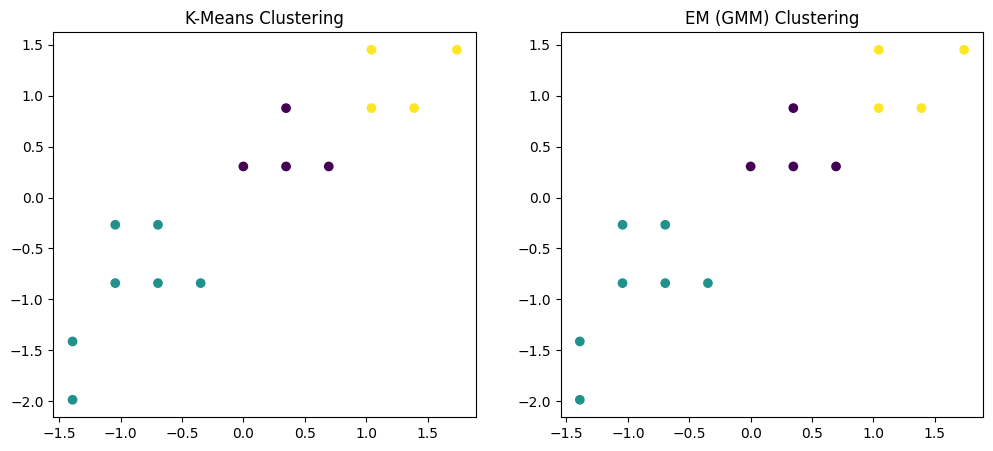

In [ ]:
# Visualization (first 2 features)
plt.figure(figsize=(12,5))   ##(width size , height size)

# K-Means Plot
plt.subplot(1,2,1)
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")

# GMM Plot
plt.subplot(1,2,2)
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=gmm_labels, cmap='viridis')
plt.title("EM (GMM) Clustering")

plt.show()

plt.subplot(1,2,1) means

Yeh screen ko divide karne ka formula hai:

1: Matlab 1 Row (line).

2: Matlab 2 Columns.

1: Matlab hum pehli (left) position par kaam kar rahe hain.

Iske baad ka saara code K-Means ke graph ke liye hai.

3. plt.scatter(...) - The Core Plot
Yeh function dots (points) draw karta hai:

X_scaled[:,0], X_scaled[:,1]: Yeh aapke data ke pehle do columns (Features) hain. X-axis par pehla column aur Y-axis par dusra column plot hota hai.

c=kmeans_labels: Yeh sabse important hai! c ka matlab hai Color. Yeh model ke labels (0, 1, 2) ke hisaab se har point ko alag rang deta hai.

cmap='viridis': Yeh ek color scheme hai jo Purple, Teal, aur Yellow ka combination use karti hai.